# RFM Segmentation + K-Means Clustering — Complete

This notebook walks through the **entire customer segmentation pipeline** from raw data to final segments.

---

## What are we trying to do?

We have a dataset of e-commerce transactions. Our goal is to **group customers into meaningful segments** based on their purchasing behavior, so a business can target each group differently (e.g., reward loyal customers, re-engage at-risk ones).

We use two techniques:
- **RFM Analysis** — scores each customer on 3 metrics: Recency, Frequency, Monetary
- **K-Means Clustering** — automatically groups customers based on those scores

---

## Pipeline Overview

```
Raw Data
  └─► Step 1: Load Data
  └─► Step 2: Clean Data
  └─► Step 3: Explore Data (EDA)
  └─► Step 4: Build RFM Table  (Recency, Frequency, Monetary per customer)
  └─► Step 5: Score RFM        (convert raw numbers to 1–5 scores)
  └─► Step 6: Find Optimal K   (how many clusters?)
  └─► Step 7: Train K-Means    (fit the model)
  └─► Step 8: Assign Segments  (label each customer)
  └─► Step 9: Visualize Results
```

## Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Make plots look nicer
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---

## Step 1 — Load Raw Data

The dataset is the **UCI Online Retail** dataset. It contains transactions from a UK-based online shop between 2010–2011.

Each row = one line item on an invoice.

| Column | Description |
|---|---|
| `InvoiceNo` | Invoice number (starts with 'C' = cancelled) |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Units purchased |
| `InvoiceDate` | Date and time of the transaction |
| `UnitPrice` | Price per unit (GBP) |
| `CustomerID` | Unique customer identifier |
| `Country` | Country of the customer |

In [2]:
RAW_PATH = '../data/raw/online_retail.csv'

df = pd.read_csv(RAW_PATH, encoding='utf-8')

print(f'Shape: {df.shape}')
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df['Country'].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


---

## Step 2 — Clean the Data

Raw transactional data is messy. We apply a series of cleaning steps **in order**. Each step removes a specific type of bad data.

The cleaning steps are:
1. Filter to UK customers only (the majority of transactions)
2. Remove rows missing a `CustomerID` or `InvoiceNo`
3. Remove duplicate rows
4. Remove cancelled transactions (`InvoiceNo` starting with 'C')
5. Remove rows where `Quantity <= 0`
6. Remove rows where `UnitPrice <= 0`
7. Add a `TotalPrice` column

In [5]:
# --- 2.1 Filter to UK only ---
df = df[df['Country'] == 'United Kingdom'].copy()
print(f'After UK filter:        {df.shape[0]:>7,} rows')

# --- 2.2 Drop rows missing CustomerID or InvoiceNo ---
df = df.dropna(subset=['CustomerID', 'InvoiceNo']).copy()
print(f'After dropping nulls:   {df.shape[0]:>7,} rows')

# --- 2.3 Drop duplicate rows ---
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode'], keep='first').reset_index(drop=True)
print(f'After dropping dupes:   {df.shape[0]:>7,} rows')

# --- 2.4 Remove cancelled transactions ---
# Cancelled invoices start with the letter 'C'
df = df[~df['InvoiceNo'].astype(str).str.startswith('C', na=False)].copy()
print(f'After removing cancels: {df.shape[0]:>7,} rows')

# --- 2.5 Remove invalid Quantity ---
df = df[df['Quantity'] > 0].copy()
print(f'After invalid qty:      {df.shape[0]:>7,} rows')

# --- 2.6 Remove invalid UnitPrice ---
df = df[df['UnitPrice'] > 0].copy()
print(f'After invalid price:    {df.shape[0]:>7,} rows')

# --- 2.7 Create TotalPrice column ---
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# --- Convert InvoiceDate to datetime ---
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'\nFinal shape: {df.shape}')
print(f'Unique customers: {df["CustomerID"].nunique():,}')

After UK filter:        495,478 rows
After dropping nulls:   361,878 rows
After dropping dupes:   351,898 rows
After removing cancels: 344,455 rows
After invalid qty:      344,455 rows
After invalid price:    344,433 rows

Final shape: (344433, 9)
Unique customers: 3,920


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---

## Step 3 — Exploratory Data Analysis (EDA)

Before building the RFM table, let's understand the data a bit.

In [7]:
print('Date range:')
print(f'  Earliest transaction: {df["InvoiceDate"].min()}')
print(f'  Latest transaction:   {df["InvoiceDate"].max()}')
print()
print(f'Total revenue: £{df["TotalPrice"].sum():,.2f}')
print(f'Average order value: £{df.groupby("InvoiceNo")["TotalPrice"].sum().mean():,.2f}')

Date range:
  Earliest transaction: 2010-12-01 08:26:00
  Latest transaction:   2011-12-09 12:49:00

Total revenue: £7,250,602.32


Average order value: £435.60


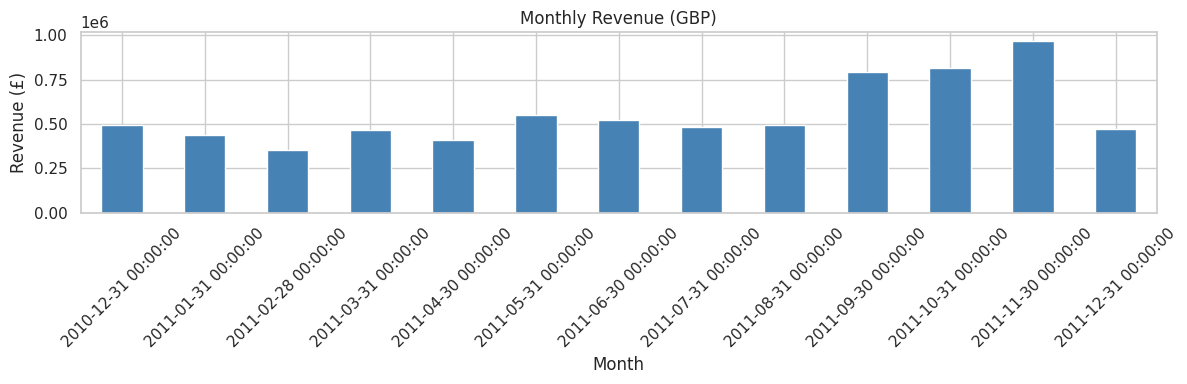

In [8]:
# Monthly revenue trend
monthly_revenue = (
    df.set_index('InvoiceDate')
    .resample('ME')['TotalPrice']
    .sum()
)

plt.figure(figsize=(12, 4))
monthly_revenue.plot(kind='bar', color='steelblue')
plt.title('Monthly Revenue (GBP)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

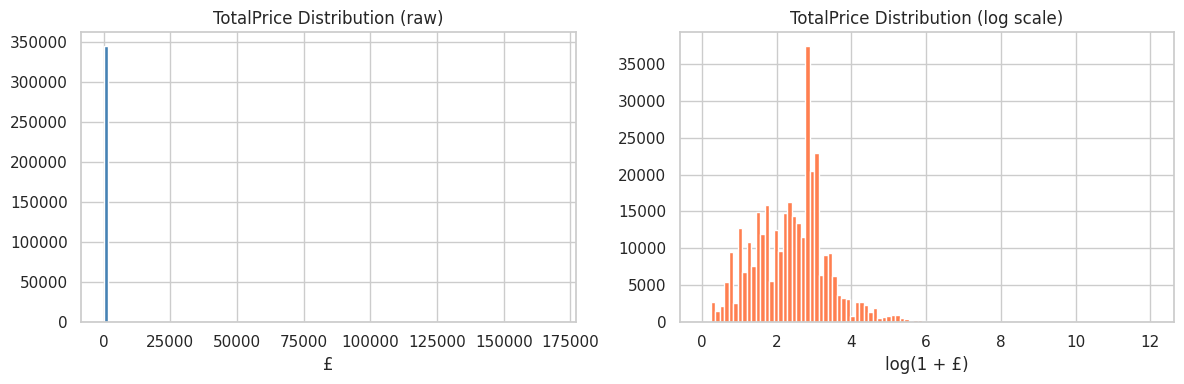

In [9]:
# Distribution of TotalPrice per transaction line
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['TotalPrice'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('TotalPrice Distribution (raw)')
axes[0].set_xlabel('£')

axes[1].hist(np.log1p(df['TotalPrice']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('TotalPrice Distribution (log scale)')
axes[1].set_xlabel('log(1 + £)')

plt.tight_layout()
plt.show()

---

## Step 4 — Build the RFM Table

RFM stands for:

| Metric | Question it answers | How to calculate |
|---|---|---|
| **R**ecency | How recently did the customer buy? | Days between their last purchase and a reference date |
| **F**requency | How often do they buy? | Number of unique invoices |
| **M**onetary | How much do they spend? | Sum of all their TotalPrice |

We group by `CustomerID` and compute all three in one step using `.agg()`.

**Reference date**: one day after the most recent transaction in the dataset. This is a standard convention — it means a customer who bought on the very last day gets Recency = 1 (not 0).

In [10]:
# Reference date = day after the last transaction in the dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date}')

rfm = (
    df.groupby('CustomerID')
    .agg(
        Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalPrice', 'sum'),
    )
    .reset_index()
)

print(f'\nRFM table shape: {rfm.shape}')
rfm.head(10)

Reference date: 2011-12-10 12:49:00

RFM table shape: (3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12747.0,2,11,4196.01
2,12748.0,1,209,32448.84
3,12749.0,4,5,4090.88
4,12820.0,3,4,942.34
5,12821.0,214,1,92.72
6,12822.0,71,2,948.88
7,12823.0,75,5,1759.50
8,12824.0,60,1,397.12
9,12826.0,3,7,1474.72


In [11]:
rfm.describe().round(2)

,CustomerID,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00,3920.00
mean,15562.06,92.21,4.25,1849.64
std,1576.59,99.53,7.20,7470.34
min,12346.00,1.00,1.00,3.75
25%,14208.75,18.00,1.00,295.26
50%,15569.50,51.00,2.00,638.06
75%,16913.25,143.00,5.00,1562.58
max,18287.00,374.00,209.00,259657.30


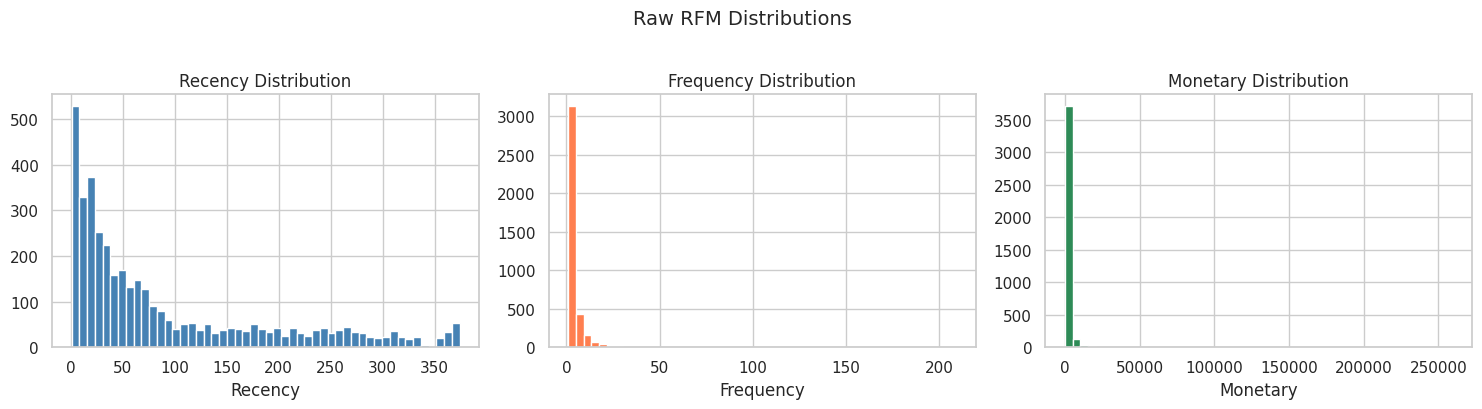

In [12]:
# Visualise raw RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['steelblue', 'coral', 'seagreen']):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)

plt.suptitle('Raw RFM Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
rfm['Recency'].value_counts()

Recency
4      100
1       87
3       84
2       74
8       67
      ... 
351      1
168      1
245      1
102      1
258      1
Name: count, Length: 348, dtype: int64

---

## Step 5 — Score the RFM Values

Raw numbers (e.g., Recency = 327 days, Monetary = £4,800) are hard to compare directly across customers. We convert them to **scores from 1 to 5** using **quantile-based binning** (`pd.qcut`).

`pd.qcut(x, q=5)` splits all customers into 5 equal-sized groups based on the data distribution.

**Important**: Recency scoring is **inverted**:
- A customer who bought 2 days ago (low Recency) is BETTER → gets score 5
- A customer who bought 300 days ago (high Recency) is WORSE → gets score 1

Frequency and Monetary are NOT inverted:
- Higher frequency → higher score
- Higher spending → higher score

In [14]:
N_BINS = 5

# Bin each metric into quantile groups
# duplicates='drop' handles ties gracefully (e.g., many customers with frequency=1)
r_cut = pd.qcut(rfm['Recency'],   q=N_BINS, duplicates='drop')
f_cut = pd.qcut(rfm['Frequency'], q=N_BINS, duplicates='drop')
m_cut = pd.qcut(rfm['Monetary'],  q=N_BINS, duplicates='drop')

# cat.codes gives a 0-based integer code for each bin (0 = lowest group)
n_r_bins = r_cut.cat.categories.size

# Recency: invert so that LOWER recency (more recent) → HIGHER score
rfm['R_Score'] = (n_r_bins - r_cut.cat.codes).astype(int)

# Frequency & Monetary: higher value → higher code → higher score (shift by +1 to start at 1)
rfm['F_Score'] = (f_cut.cat.codes + 1).astype(int)
rfm['M_Score'] = (m_cut.cat.codes + 1).astype(int)

# Overall RFM Score = sum of the three (range: 3 to 15)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('Score ranges:')
for col in ['R_Score', 'F_Score', 'M_Score', 'RFM_Score']:
    print(f'  {col}: {rfm[col].min()} – {rfm[col].max()}')

rfm.head(10)

Score ranges:
  R_Score: 1 – 5
  F_Score: 1 – 4
  M_Score: 1 – 5
  RFM_Score: 3 – 14


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,7
1,12747.0,2,11,4196.01,5,4,5,14
2,12748.0,1,209,32448.84,5,4,5,14
3,12749.0,4,5,4090.88,5,3,5,13
4,12820.0,3,4,942.34,5,3,4,12
5,12821.0,214,1,92.72,1,1,1,3
6,12822.0,71,2,948.88,3,1,4,8
7,12823.0,75,5,1759.50,2,3,4,9
8,12824.0,60,1,397.12,3,1,2,6
9,12826.0,3,7,1474.72,5,4,4,13


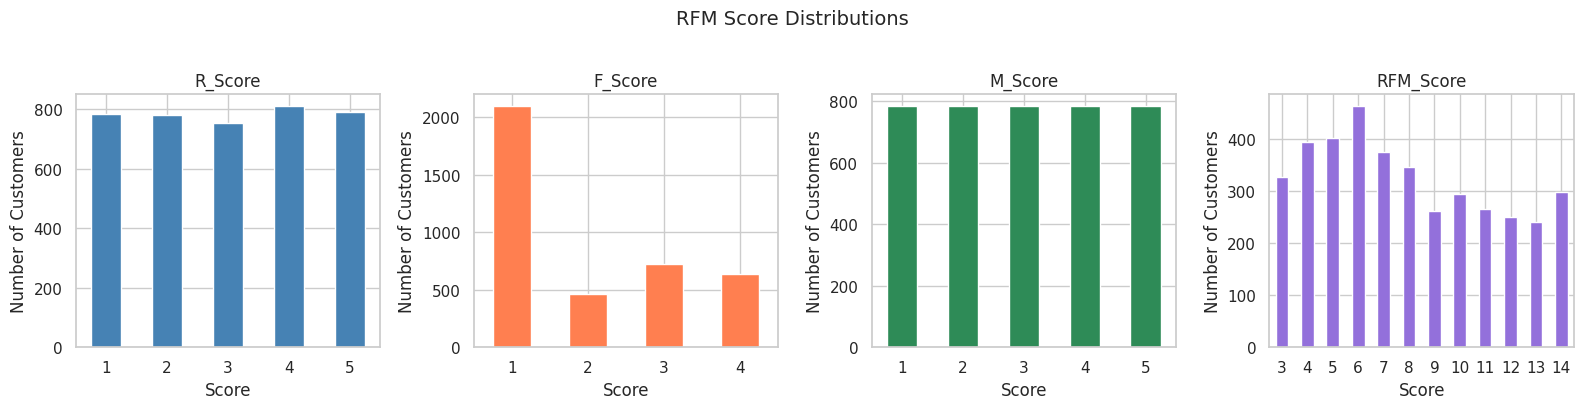

In [15]:
# Score distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col, color in zip(axes,
                           ['R_Score', 'F_Score', 'M_Score', 'RFM_Score'],
                           ['steelblue', 'coral', 'seagreen', 'mediumpurple']):
    rfm[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Customers')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('RFM Score Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Step 6 — Find the Optimal Number of Clusters (K)

K-Means requires us to decide **how many clusters (K)** to use upfront. We evaluate a range of K values using two methods:

### Elbow Method
Plots the **inertia** (sum of squared distances from each point to its cluster centre) for each K. We look for the "elbow" — the point where adding more clusters gives diminishing returns.

### Silhouette Score
Measures how well each customer fits its own cluster vs. neighbouring clusters. Ranges from -1 to 1. **Higher is better.** We pick the K with the highest silhouette score.

### Why log1p + StandardScaler?
K-Means is sensitive to scale. Monetary values (hundreds to thousands) would dominate Recency (tens to hundreds) without normalisation.
- `log1p(x)` = log(1 + x): compresses the long tail of skewed distributions
- `StandardScaler`: standardises each feature to mean=0, std=1

In [16]:
# Prepare feature matrix
X = rfm[['Recency', 'Frequency', 'Monetary']].values

# Apply log1p to reduce skewness, then standardise
X_log = np.log1p(X)
X_scaled = StandardScaler().fit_transform(X_log)

print('Feature matrix shape:', X_scaled.shape)
print('Mean after scaling (should be ~0):', X_scaled.mean(axis=0).round(6))
print('Std after scaling  (should be ~1):', X_scaled.std(axis=0).round(6))

Feature matrix shape: (3920, 3)
Mean after scaling (should be ~0): [0. 0. 0.]
Std after scaling  (should be ~1): [1. 1. 1.]


In [17]:
# Evaluate K from 2 to 10
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f'  K={k}  |  Inertia: {km.inertia_:>10.2f}  |  Silhouette: {silhouette_scores[-1]:.4f}')

  K=2  |  Inertia:    5814.62  |  Silhouette: 0.4353
  K=3  |  Inertia:    4341.88  |  Silhouette: 0.3413
  K=4  |  Inertia:    3506.05  |  Silhouette: 0.3384
  K=5  |  Inertia:    2933.78  |  Silhouette: 0.3187
  K=6  |  Inertia:    2533.68  |  Silhouette: 0.3156
  K=7  |  Inertia:    2256.45  |  Silhouette: 0.3115
  K=8  |  Inertia:    2063.47  |  Silhouette: 0.3073
  K=9  |  Inertia:    1899.01  |  Silhouette: 0.2840
  K=10  |  Inertia:    1760.84  |  Silhouette: 0.2808


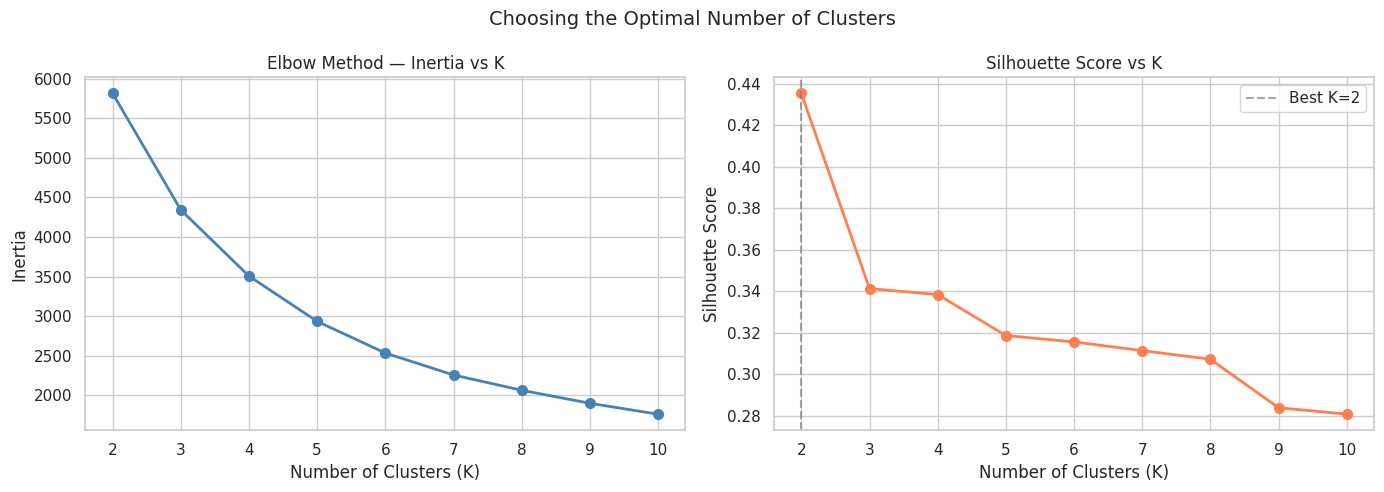


Best K by silhouette score: 2


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(list(k_range), silhouette_scores, 'o-', color='coral', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k, color='gray', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('Choosing the Optimal Number of Clusters', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nBest K by silhouette score: {best_k}')

---

## Step 7 — Train K-Means with K = 4

We choose **K = 4** as it gives a good balance between:
- **Interpretability** — 4 segments is easy for a business to act on
- **Statistical quality** — competitive silhouette score

The model learns which customers belong together by minimising the distance between customers and their cluster centre.

> `n_init=10` means the algorithm runs 10 times with different random starting points and picks the best result — this avoids getting stuck in a bad local minimum.

In [19]:
N_CLUSTERS = 4

# We need a fresh scaler that we'll reuse for prediction
scaler = StandardScaler()
X_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']].values)
X_scaled = scaler.fit_transform(X_log)

# Fit K-Means
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Predict cluster labels for each customer
labels = kmeans.predict(X_scaled)

rfm['Cluster'] = labels

print('Customers per cluster:')
print(rfm['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0    1432
1     643
2    1061
3     784
Name: count, dtype: int64


---

## Step 8 — Assign Business-Meaningful Segment Names

K-Means assigns cluster numbers (0, 1, 2, 3) — these have no inherent meaning. We map them to business names by **ranking each cluster by its quality**.

**Quality score formula:**
```
Score = (mean Frequency × mean Monetary) / (mean Recency + 1)
```

This rewards clusters that:
- Buy **frequently** (high Frequency)
- Spend **a lot** (high Monetary)
- Bought **recently** (low Recency)

The cluster with the highest score becomes "Champions", next becomes "Loyal Customers", and so on.

In [20]:
SEGMENT_NAMES = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'At Risk',
]

# Compute mean RFM per cluster
centroids = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Quality score: frequent + high-value + recent buyers rank highest
centroids['Quality_Score'] = (
    centroids['Frequency'] * centroids['Monetary'] / (centroids['Recency'] + 1)
)

print('Cluster centroids with quality scores:')
print(centroids.round(2))

# Map cluster number → rank (0 = best)
rank_map = (centroids['Quality_Score'].rank(ascending=False).astype(int) - 1).to_dict()

# Assign segment name based on rank
rfm['Segment'] = rfm['Cluster'].map(lambda c: SEGMENT_NAMES[rank_map[c]])

print('\nCustomers per segment:')
print(rfm['Segment'].value_counts())

Cluster centroids with quality scores:
         Recency  Frequency  Monetary  Quality_Score
Cluster                                             
0         185.00       1.32    323.11           2.30
1          11.73      13.55   7130.59        7589.53
2          69.30       4.17   1701.63         101.04
3          19.73       2.05    507.03          50.18

Customers per segment:
Segment
At Risk                1432
Loyal Customers        1061
Potential Loyalists     784
Champions               643
Name: count, dtype: int64


In [21]:
# Segment profile: mean RFM values per segment
segment_profile = (
    rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary', 'RFM_Score']]
    .mean()
    .round(2)
    .sort_values('RFM_Score', ascending=False)
)
print('Segment profile (mean values):')
segment_profile

Segment profile (mean values):


,Recency,Frequency,Monetary,RFM_Score
Segment,,,,
Champions,11.73,13.55,7130.59,13.27
Loyal Customers,69.30,4.17,1701.63,9.45
Potential Loyalists,19.73,2.05,507.03,7.98
At Risk,185.00,1.32,323.11,4.53


---

## Step 9 — Visualise the Results

Now let's explore what the segments look like visually.

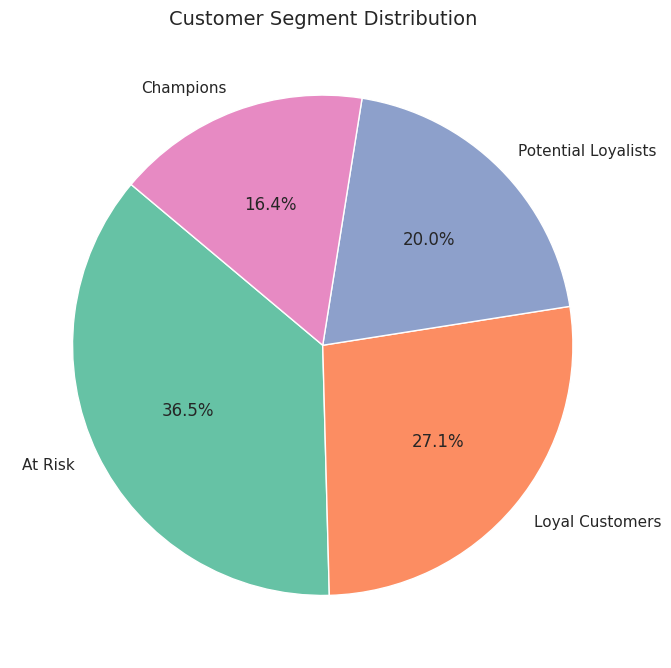

In [22]:
# Segment size (pie chart)
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(segment_counts))
)
plt.title('Customer Segment Distribution', fontsize=14)
plt.tight_layout()
plt.show()

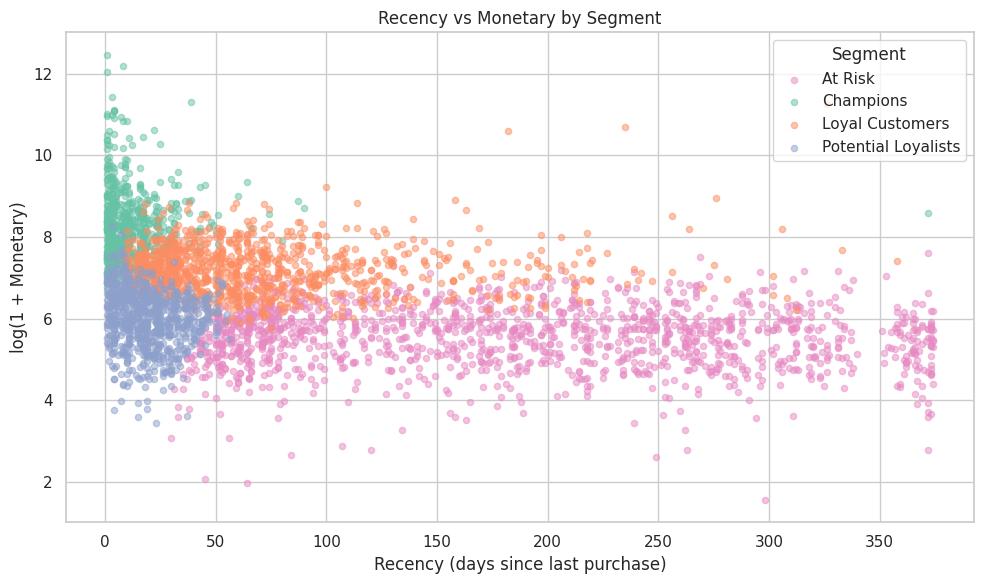

In [23]:
# Scatter plot: Recency vs Monetary, coloured by segment
palette = dict(zip(SEGMENT_NAMES, sns.color_palette('Set2', len(SEGMENT_NAMES))))

plt.figure(figsize=(10, 6))
for segment, group in rfm.groupby('Segment'):
    plt.scatter(
        group['Recency'],
        np.log1p(group['Monetary']),
        label=segment,
        alpha=0.5,
        s=20,
        color=palette[segment]
    )

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('log(1 + Monetary)')
plt.title('Recency vs Monetary by Segment')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

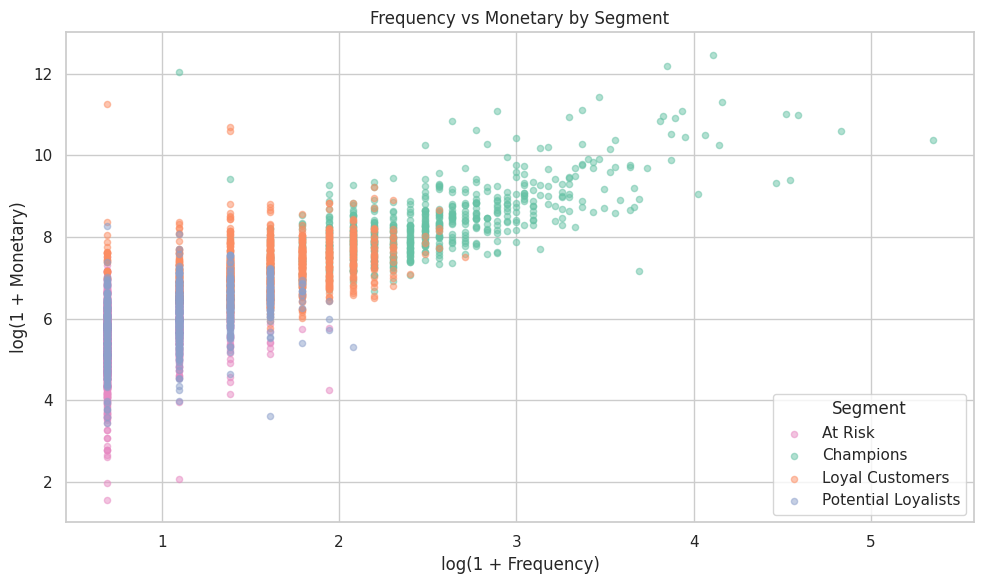

In [24]:
# Scatter plot: Frequency vs Monetary, coloured by segment
plt.figure(figsize=(10, 6))
for segment, group in rfm.groupby('Segment'):
    plt.scatter(
        np.log1p(group['Frequency']),
        np.log1p(group['Monetary']),
        label=segment,
        alpha=0.5,
        s=20,
        color=palette[segment]
    )

plt.xlabel('log(1 + Frequency)')
plt.ylabel('log(1 + Monetary)')
plt.title('Frequency vs Monetary by Segment')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

/tmp/ipykernel_45896/3387065164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_45896/3387065164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_45896/3387065164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


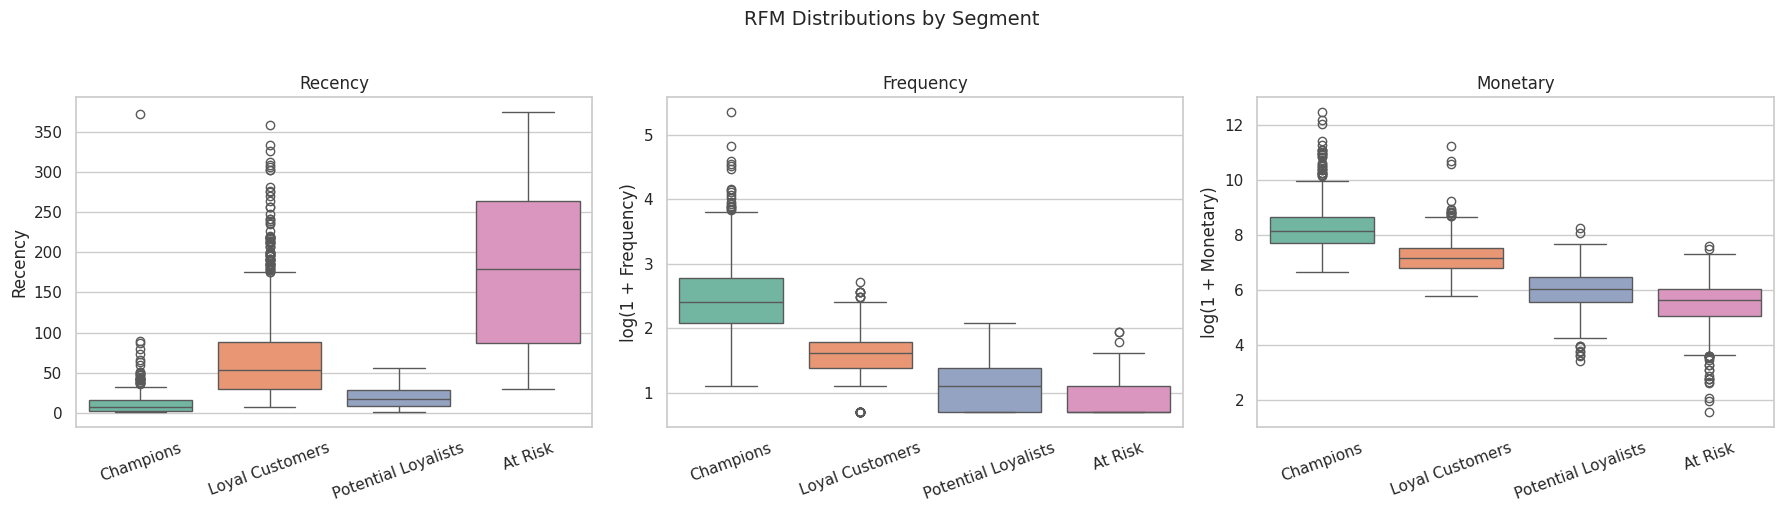

In [25]:
# Box plots for each RFM metric across segments
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk']
colors = sns.color_palette('Set2', len(SEGMENT_NAMES))

for ax, (metric, log_scale) in zip(axes, [('Recency', False), ('Frequency', True), ('Monetary', True)]):
    plot_data = rfm.copy()
    if log_scale:
        plot_data[metric] = np.log1p(plot_data[metric])
        ylabel = f'log(1 + {metric})'
    else:
        ylabel = metric

    sns.boxplot(
        data=plot_data,
        x='Segment',
        y=metric,
        order=[s for s in segment_order if s in rfm['Segment'].unique()],
        palette='Set2',
        ax=ax
    )
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('RFM Distributions by Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

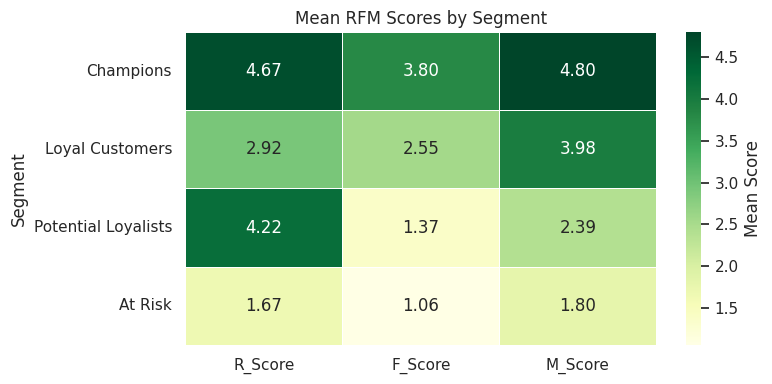

In [26]:
# Heatmap: mean RFM scores per segment
heatmap_data = (
    rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']]
    .mean()
    .reindex([s for s in segment_order if s in rfm['Segment'].unique()])
    .round(2)
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Score'}
)
plt.title('Mean RFM Scores by Segment')
plt.tight_layout()
plt.show()

---

## Step 10 — Save the Final Segmented Data

In [27]:
OUTPUT_PATH = '../data/processed/rfm_segments.csv'

rfm.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

print(f'Saved to: {OUTPUT_PATH}')
print(f'Shape: {rfm.shape}')
rfm.head()

Saved to: ../data/processed/rfm_segments.csv
Shape: (3920, 10)


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
0,12346.0,326,1,77183.60,1,1,5,7,2,Loyal Customers
1,12747.0,2,11,4196.01,5,4,5,14,1,Champions
2,12748.0,1,209,32448.84,5,4,5,14,1,Champions
3,12749.0,4,5,4090.88,5,3,5,13,1,Champions
4,12820.0,3,4,942.34,5,3,4,12,3,Potential Loyalists


---

## Summary

Here's what we built, step by step:

| Step | What we did | Key tool |
|---|---|---|
| 1 | Loaded raw transaction data | `pd.read_csv` |
| 2 | Cleaned data (nulls, dupes, cancels, invalid rows) | pandas filtering |
| 3 | Explored the data (revenue trends, distributions) | matplotlib / seaborn |
| 4 | Built the RFM table — one row per customer | `df.groupby().agg()` |
| 5 | Scored R, F, M on a 1–5 scale | `pd.qcut` |
| 6 | Found the best K using Elbow + Silhouette | `sklearn.metrics.silhouette_score` |
| 7 | Trained K-Means with K=4 on log-scaled, standardised data | `sklearn.cluster.KMeans` |
| 8 | Mapped cluster numbers → business segment names | quality score ranking |
| 9 | Visualised segments with scatter plots, box plots, heatmap | matplotlib / seaborn |
| 10 | Saved the final result | `df.to_csv` |

---

### Business Interpretation of Segments

| Segment | Profile | Recommended Action |
|---|---|---|
| **Champions** | Bought recently, buy often, spend the most | Reward them. Ask for reviews. Early access to new products. |
| **Loyal Customers** | Buy regularly, good lifetime value | Upsell higher-tier products. Loyalty programs. |
| **Potential Loyalists** | Recent buyers, not yet frequent | Onboarding emails, welcome offers, nurture relationship. |
| **At Risk** | Used to buy frequently, now inactive | Win-back campaigns, special discounts, personal outreach. |